# 02 — Build the Bayesian MMM (PyMC-Marketing)

**Goal:** fit a Bayesian Marketing Mix Model, validate it, decompose sales into channel
contributions, compute ROI, and find a better budget allocation.

Prereq: run notebook 01 first (it creates `../data/model_data.csv`).

⚠️ The fitting cell takes **10–40 minutes** on a laptop. That's normal for MCMC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az                     # arviz = analysis of Bayesian model results

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

plt.rcParams["figure.figsize"] = (12, 4)

In [2]:
# Load the table we built in notebook 01
data = pd.read_csv("../data/model_data.csv", parse_dates=["date"])

channels = ["tv", "digital_video", "search", "social", "display", "audio", "print_mail"]
controls = ["consumer_sentiment", "gas_price", "store_count", "markdown",
            "hol_blackfriday", "hol_christmas", "hol_thanksgiving", "hol_july4", "hol_primeday"]

# X = everything the model uses to explain sales; y = sales itself
X = data[["date"] + channels + controls]
y = data["sales"]
print(X.shape, "weeks of data")

(209, 17) weeks of data


## Model specification

Two key choices (be ready to defend both in a viva/interview):

- **GeometricAdstock(l_max=8)** — media effect can carry over up to 8 weeks; the decay
  rate per channel is *learned from the data*.
- **LogisticSaturation()** — diminishing returns; the curve shape per channel is learned.

`yearly_seasonality=2` adds Fourier terms so the model captures annual cycles itself.

In [3]:
mmm = MMM(
    date_column="date",
    channel_columns=channels,
    control_columns=controls,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

In [4]:
# FIT — this is the slow cell (10–40 min). Go read LEARNING_GUIDE section 5 while it runs.
# 4 chains of MCMC sampling; random_seed makes results reproducible.
mmm.fit(X, y, chains=4, target_accept=0.9, random_seed=42)
mmm.sample_posterior_predictive(X, extend_idata=True, combined=True)
print("Done!")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


/opt/miniconda3/envs/mmm/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 153 seconds.


There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


/opt/miniconda3/envs/mmm/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/opt/miniconda3/envs/mmm/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Done!


## Validate before you trust it

1. **r_hat < 1.01** for all parameters → chains agree → sampling converged.
2. **Divergences ~ 0** → sampler explored the posterior properly.
3. **Posterior predictive check** → simulated sales should hug actual sales.

In [5]:
# 1 & 2: convergence diagnostics
summary = az.summary(mmm.idata, var_names=["adstock_alpha", "saturation_lam", "saturation_beta"])
print("Max r_hat:", summary["r_hat"].max())
n_div = int(mmm.idata["sample_stats"]["diverging"].sum())
print("Divergences:", n_div)
summary

Max r_hat: 1.0
Divergences: 1


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
adstock_alpha[tv],0.394,0.145,0.098,0.646,0.003,0.003,2440.0,1424.0,1.0
adstock_alpha[digital_video],0.240,0.186,0.000,0.577,0.002,0.003,4448.0,2263.0,1.0
adstock_alpha[search],0.198,0.152,0.000,0.477,0.002,0.002,3369.0,2007.0,1.0
adstock_alpha[social],0.236,0.186,0.000,0.579,0.002,0.003,5858.0,2209.0,1.0
adstock_alpha[display],0.261,0.190,0.000,0.607,0.002,0.003,4961.0,2070.0,1.0
adstock_alpha[audio],0.324,0.222,0.000,0.716,0.003,0.003,5204.0,2447.0,1.0
adstock_alpha[print_mail],0.360,0.234,0.001,0.753,0.004,0.003,3392.0,1827.0,1.0
saturation_lam[tv],1.265,0.678,0.238,2.502,0.012,0.012,2937.0,2215.0,1.0
saturation_lam[digital_video],2.192,1.563,0.087,5.006,0.023,0.031,3536.0,2459.0,1.0
saturation_lam[search],1.718,1.004,0.191,3.562,0.018,0.017,2634.0,2273.0,1.0


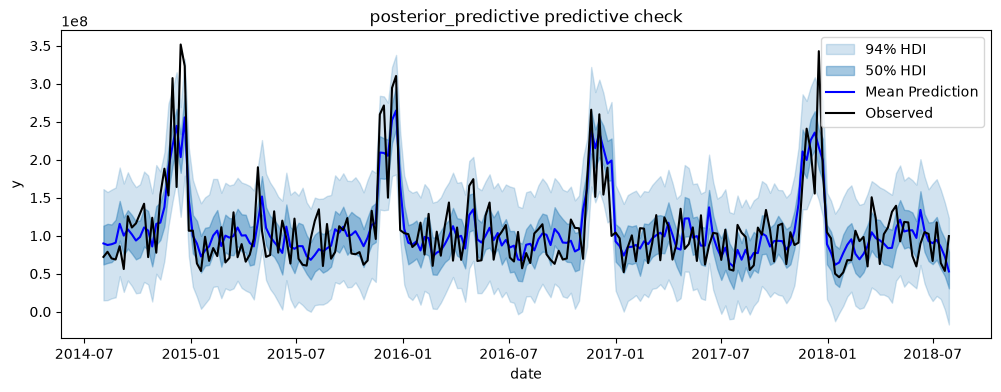

In [6]:
# 3: posterior predictive check — model's simulated sales (band) vs actual (line)
mmm.plot_posterior_predictive(original_scale=True)
plt.show()

## Decompose: where do sales come from?

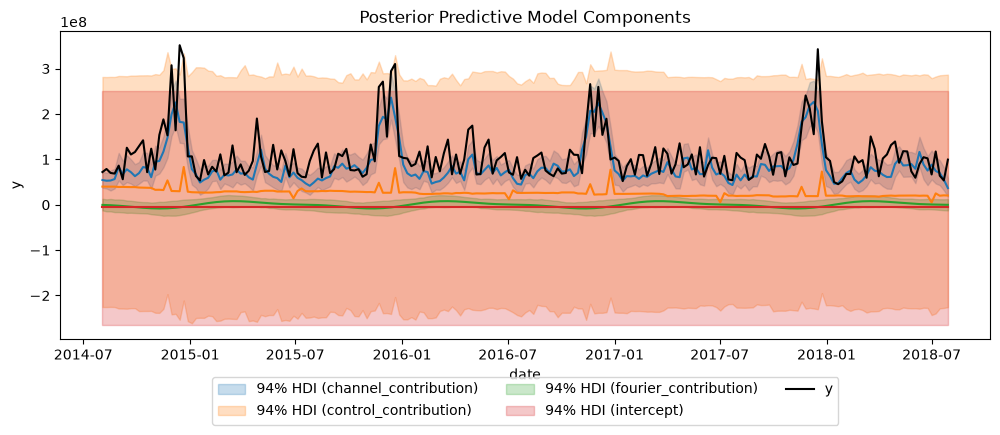

In [7]:
# Stacked decomposition of sales into baseline + each channel + controls over time
mmm.plot_components_contributions(original_scale=True)
plt.show()

In [8]:
# Channel contribution share vs spend share — the classic MMM output.
# A channel contributing MORE than its spend share is punching above its weight.
contributions = mmm.compute_mean_contributions_over_time(original_scale=True)
channel_contrib = contributions[channels].sum()
spend_totals = data[channels].sum()

roi_table = pd.DataFrame({
    "total_spend_$": spend_totals.round(0),
    "attributed_sales_$": channel_contrib.round(0),
    "ROI (sales per $ spent)": (channel_contrib / spend_totals).round(2),
    "spend_share_%": (spend_totals / spend_totals.sum() * 100).round(1),
    "contribution_share_%": (channel_contrib / channel_contrib.sum() * 100).round(1),
}).sort_values("ROI (sales per $ spent)", ascending=False)

roi_table

,total_spend_$,attributed_sales_$,ROI (sales per $ spent),spend_share_%,contribution_share_%
digital_video,3865648.0,9.205680e+08,238.14,0.8,5.1
tv,35145152.0,4.881713e+09,138.90,7.2,27.3
social,21320204.0,9.898880e+08,46.43,4.3,5.5
display,45115576.0,2.080274e+09,46.11,9.2,11.6
search,130861972.0,5.764937e+09,44.05,26.7,32.2
audio,26428181.0,1.044828e+09,39.53,5.4,5.8
print_mail,228187236.0,2.223768e+09,9.75,46.5,12.4


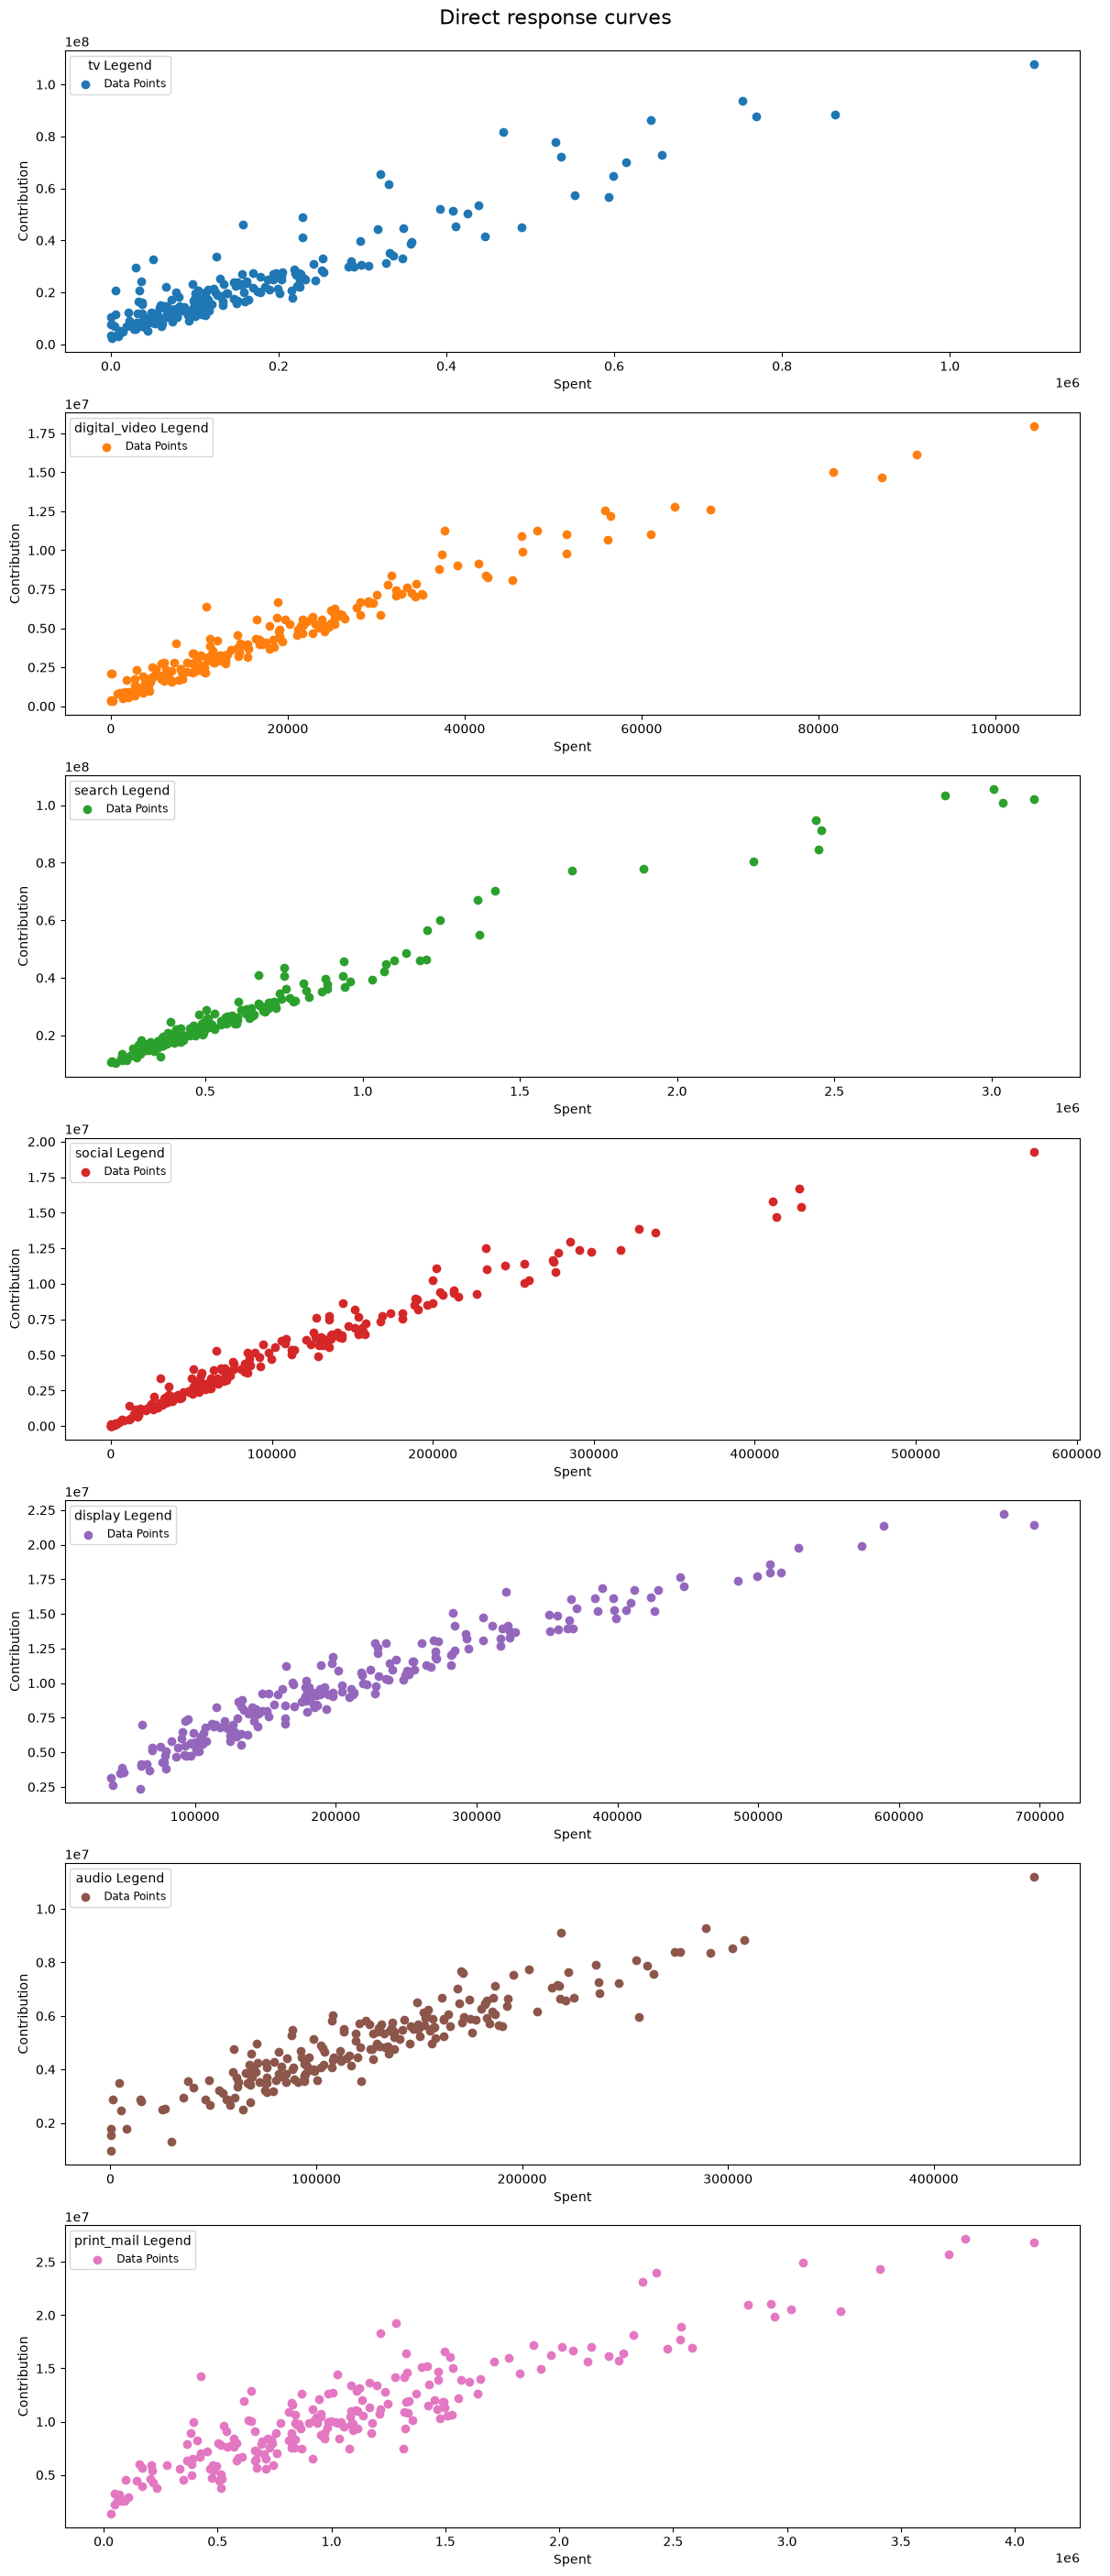

In [9]:
# Saturation curves: is each channel still efficient (steep region) or saturated (flat)?
# THE chart for the "where should the next dollar go" conversation.
mmm.plot_direct_contribution_curves()
plt.show()

## Budget optimization

PyMC-Marketing includes an optimizer that moves budget along the fitted saturation
curves to maximize predicted contribution at the same total spend.

> **Fixed 2026-07-03:** this cell used to be flagged as possibly broken. Root cause found:
> `pip install -r requirements.txt` was pulling the newest pymc (5.25+), but pymc-marketing
> 0.15.1's optimizer imports a function pymc renamed internally, so `import BudgetOptimizer`
> raised `ImportError: cannot import name 'rvs_in_graph'`. Fix: requirements.txt now pins
> `pymc==5.23.0` alongside `pymc-marketing==0.15.1` — tested working together. If you ever
> upgrade pymc-marketing later, re-check this pin.

In [10]:
# Budget optimization with REALISTIC planning constraints.
#
# Why constraints matter:
# The first optimizer run allowed every channel to go anywhere from $0 to the full budget.
# That is mathematically valid but operationally unrealistic: a real CMO cannot instantly
# move half the budget out of print/mail and 10x a small digital-video program.
#
# Business framing:
# Treat this as a practical next-quarter reallocation scenario, not a fantasy optimum.
# - Keep every active channel funded enough to avoid turning the lights off overnight.
# - Let underfunded/high-ROI channels scale, but cap growth to plausible operating limits.
# - Force print/mail to test a controlled reduction because it has high spend share and low ROI.

# Average weekly spend by channel over the last year. This is our current operating baseline.
recent = data.tail(52)
current_weekly = recent[channels].mean()
avg_weekly_budget = current_weekly.sum()
print(f"Avg weekly media budget (last 52 wks): ${avg_weekly_budget:,.0f}")

# Channel-specific planning bounds for ONE average week.
# Each tuple means: optimizer may spend between (lower_bound, upper_bound) for that channel.
# These are deliberately conservative enough to defend in an interview.
bound_multipliers = {
    "tv": (0.60, 2.50),             # TV can scale, but production/inventory limit speed.
    "digital_video": (0.50, 4.00),  # Tiny base + high ROI, so allow larger % growth.
    "search": (0.70, 1.75),         # Search can scale, but demand is not infinite.
    "social": (0.60, 1.75),         # Moderate growth room.
    "display": (0.60, 1.50),        # Display can grow, but avoid blindly adding cheap reach.
    "audio": (0.60, 1.75),          # Some scale room, still bounded.
    "print_mail": (0.50, 0.85),     # Test a controlled cut from the over-weighted legacy channel.
}

budget_bounds = {
    channel: (
        float(current_weekly[channel] * lower),
        float(current_weekly[channel] * upper),
    )
    for channel, (lower, upper) in bound_multipliers.items()
}

# Sanity check: the total budget must fit between the sum of all lower and upper bounds.
min_possible = sum(lower for lower, upper in budget_bounds.values())
max_possible = sum(upper for lower, upper in budget_bounds.values())
print(f"Feasible budget range: ${min_possible:,.0f} to ${max_possible:,.0f}")
print(f"Budget to allocate:     ${avg_weekly_budget:,.0f}")

# Optimize allocation of that same weekly budget over an 8-week horizon.
# optimize_budget returns a TUPLE: (allocation, scipy_optimize_result) - unpack both.
allocation, opt_result = mmm.optimize_budget(
    budget=avg_weekly_budget,
    num_periods=8,
    budget_bounds=budget_bounds,
)
print("Optimizer converged:", opt_result.success)

# Convert xarray allocation into a simple business table.
recommended_weekly = allocation.to_series().reindex(channels)
optimizer_table = pd.DataFrame({
    "current_weekly_$": current_weekly,
    "recommended_weekly_$": recommended_weekly,
})
optimizer_table["change_$"] = optimizer_table["recommended_weekly_$"] - optimizer_table["current_weekly_$"]
optimizer_table["change_%"] = optimizer_table["change_$"] / optimizer_table["current_weekly_$"] * 100
optimizer_table["current_share_%"] = optimizer_table["current_weekly_$"] / avg_weekly_budget * 100
optimizer_table["recommended_share_%"] = optimizer_table["recommended_weekly_$"] / avg_weekly_budget * 100

optimizer_table = optimizer_table.round({
    "current_weekly_$": 0,
    "recommended_weekly_$": 0,
    "change_$": 0,
    "change_%": 1,
    "current_share_%": 1,
    "recommended_share_%": 1,
}).sort_values("change_$", ascending=False)

optimizer_table


Avg weekly media budget (last 52 wks): $2,113,548
Feasible budget range: $1,273,386 to $3,195,181
Budget to allocate:     $2,113,548


/opt/miniconda3/envs/mmm/lib/python3.11/site-packages/pymc_marketing/mmm/budget_optimizer.py:240: UserWarning: Using default equality constraint
  self.set_constraints(


Optimizer converged: True


,current_weekly_$,recommended_weekly_$,change_$,change_%,current_share_%,recommended_share_%
tv,136500.0,317823.0,181324.0,132.8,6.5,15.0
social,175997.0,307995.0,131998.0,75.0,8.3,14.6
audio,127248.0,222684.0,95436.0,75.0,6.0,10.5
digital_video,21379.0,85517.0,64138.0,300.0,1.0,4.0
display,281534.0,317823.0,36290.0,12.9,13.3,15.0
search,722419.0,521581.0,-200838.0,-27.8,34.2,24.7
print_mail,648471.0,340124.0,-308348.0,-47.5,30.7,16.1


## Your business recommendation (portfolio draft)

Use the constrained optimizer output above, not the unconstrained equal-split result.
The recommendation should be framed as a **next-quarter test budget**, because MMM is
strongest when it guides controlled reallocations rather than claiming perfect certainty.

Suggested wording:

> The model suggests that `print_mail` is materially over-weighted: it receives the
> largest share of media spend but produces a much smaller share of attributed sales.
> A constrained reallocation scenario reduces print/mail while increasing channels with
> stronger modeled returns, especially digital video, TV, and search. I would recommend
> implementing this as a controlled next-quarter test, monitoring weekly revenue,
> channel-level pacing, and incrementality signals before making a larger permanent shift.

### Why this is defensible
1. The recommendation keeps total weekly budget constant.
2. It uses operational bounds, so the answer is not a fantasy all-or-nothing allocation.
3. It challenges the biggest business issue in the data: legacy print/mail spend is large,
   while its modeled ROI and contribution share are weak.
4. It treats MMM as decision support, not a magic truth machine.

### Next steps to make this portfolio-grade
1. Holdout validation: refit on the first 80% of weeks, test predictions on the last 20%.
2. Sensitivity: try `l_max=4` and `l_max=12` - do ROI rankings change?
3. Rerun with a slightly higher `target_accept` if you want to eliminate the 1 divergence.
4. Write a 1-page case study: problem -> method -> validation -> recommendation.
5. Push to GitHub with a clean README and the ROI/reallocation table.
